In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## QQ plot: use to find that given distribution is normal or not

**1. Method1: (a bit lengthy)**

**a. first dataset**

In [2]:
df = sns.load_dataset("../datasets/iris")

<Axes: xlabel='sepal_length', ylabel='Density'>

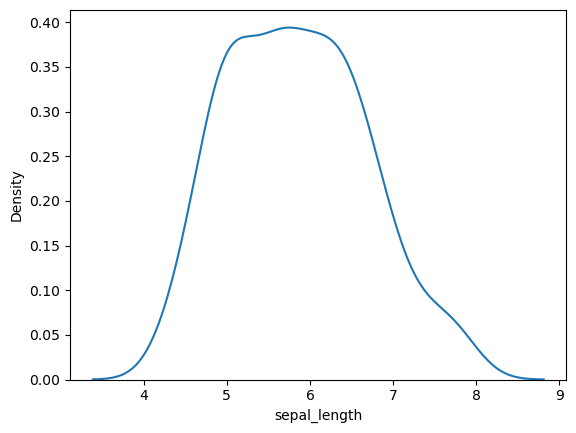

In [3]:
sns.kdeplot(df["sepal_length"])     # iris dataset mein sirf petral length column ka kdeplot banaya hai 

In [9]:
a  = sorted(df["sepal_length"].tolist())    # humne petal length ki saari values nikalke, sort krke use list mein store krdiya for further operations

In [14]:
y_quant = []
for i in range(1,101):
    y_quant.append(np.percentile(a,i))

#ab humne 1 se 100 percentiles nikaldiye (loop lagake in a) and then use empty list y_quant mein store krdiya

**b. 2nd dataset: "normal distribution" jo hamein pata hai and isi se hi hum first dataset ke percentile ko compare krenge**

In [12]:
sample = np.random.normal(loc=0, scale=1,size=1000)   # normal distribution jiska mean=0 and std=1 hai

In [15]:
x_quant = []
for i in range(1,101):
    x_quant.append(np.percentile(sample,i))

#similarly normal distribution ke bhi 100 percentiles find krke use x_quant empty list mein store krna hai

<Axes: >

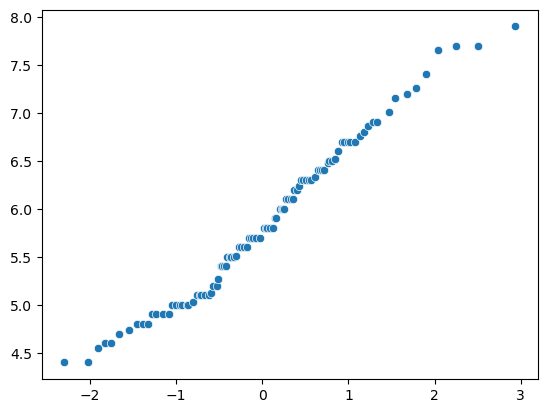

In [16]:
sns.scatterplot(x=x_quant, y=y_quant)  #now scatterplot se hum dono ke percentiles ko compare krenge

**As above plot straight line ke kaafi aaspaas hai, This means yeh almost normal distribution hai but not clearly but vaguely**

**2. Method2: use statsmodels library:**

In [28]:
import statsmodels.api as sm       #library used for QQ plot
import matplotlib.pyplot as plt

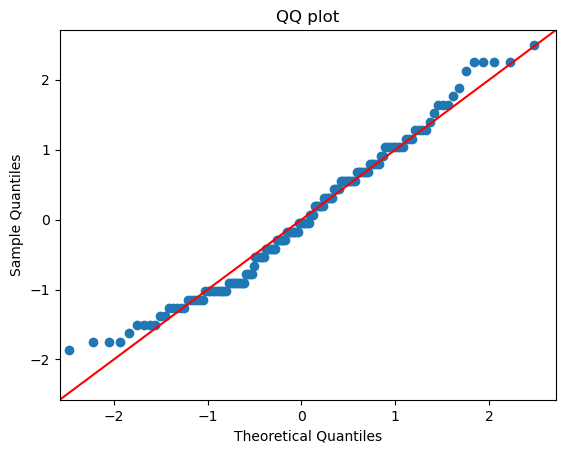

In [22]:
# create QQ plot of 2 datasets:
fig= sm.qqplot(df["sepal_length"], line="45", fit=True)     # here line 45 degree bhi ssath hai jisse better comparison hoga

#Add title and labels:
plt.title("QQ plot")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.show()

## 1. Uniform distribution:

In [40]:
# generate set of random data:  
import scipy.stats as stats     #use  another library used for fitting distributions

x= np.random.uniform(low=0, high=1, size=1000)   # uniform distribution from range(0,1)

# Fit uniform distribution to data:  yeh externally theoretically uniform distribution hai
parameters = stats.uniform.fit(x)
distribution = stats.uniform(loc=parameters[0], scale=parameters[1])    # yeh bhi distribution hamne 0 and 1 ki range mein hi fit kiya

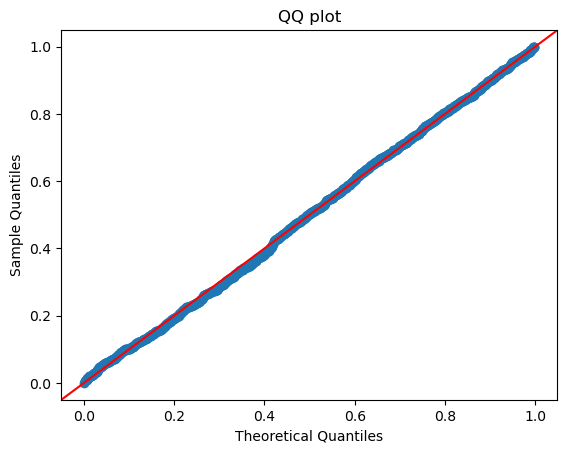

In [32]:
# Create QQ plot using uniform distribution:
fig= sm.qqplot(x, dist= distribution, line="45")   
# pichle vaale mein normal distribution as "dist" default tha yahan hamein batana  pdega and yahan fit=True lagane ki zarurat nhi hai

#Add title and labels:
plt.title("QQ plot")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.show()

## 2. Pareto distribution: use in exponentional distribution

**Method 1: For this we plot log-log plot:**

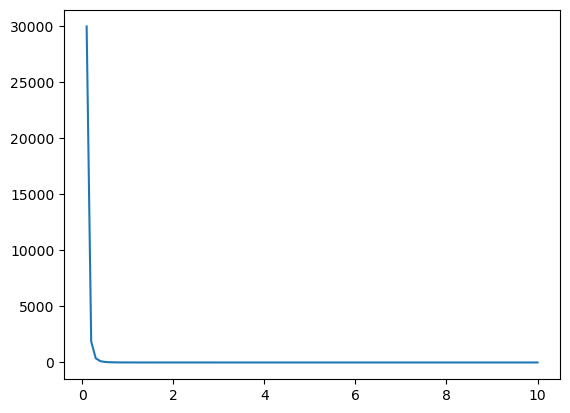

In [36]:
# define the parameter of Pareto distribution:
alpha = 3
xm = 1

# create array of x values:
x = np.linspace(0.1,10,100)

# calculate y values of pareto distribution : which is prob. density function
y = alpha * (xm**alpha) / x**((alpha + 1))

plt.plot(x,y)

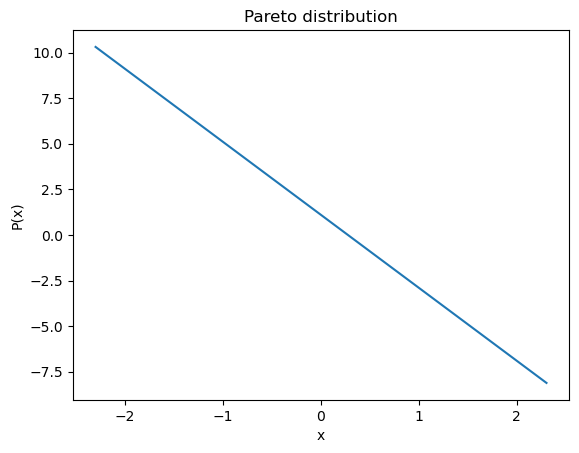

In [38]:
# now create log-log table and add lables and title: dono x and y ka log lena hai and unka graph banana hai
plt.plot(np.log(x), np.log(y))
plt.xlabel("x")
plt.ylabel("P(x)")
plt.title("Pareto distribution")
plt.show()

**This line proves that above graph is log normal distribution**  

**Method 2: QQ plot also: isme ek distribution hamein pata hai ki pareto distribution hai and other se relation find krna hai**

(array([959.,  28.,   6.,   2.,   1.,   2.,   1.,   0.,   0.,   1.]),
 array([ 1.00029922,  5.2367818 ,  9.47326439, 13.70974697, 17.94622956,
        22.18271214, 26.41919472, 30.65567731, 34.89215989, 39.12864248,
        43.36512506]),
 <BarContainer object of 10 artists>)

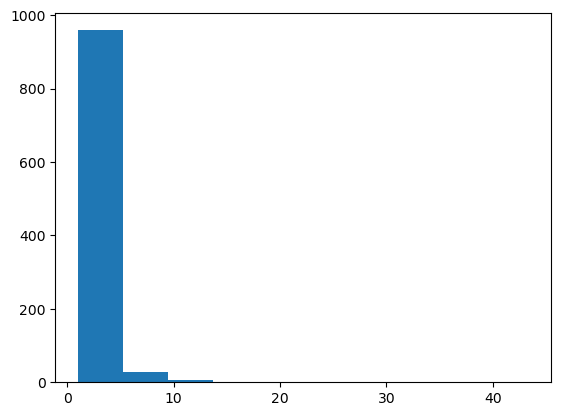

In [47]:
# define parametr of pareto distribution:
alpha = 2
xm = 1

# generate set of random data from pareto distribution:
x = stats.pareto.rvs(b=alpha, scale=xm, size=1000)     # here exponetion part is b and x is xm:  as y~xm**alpha
plt.hist(x)

In [48]:
# Fit Pareto distribution to data:  
parameters = stats.pareto.fit(x, floc=0)
distribution = stats.pareto(b=parameters[0], scale=parameters[2])    # yeh bhi distribution hamne 0 and 1 ki range mein hi fit kiya

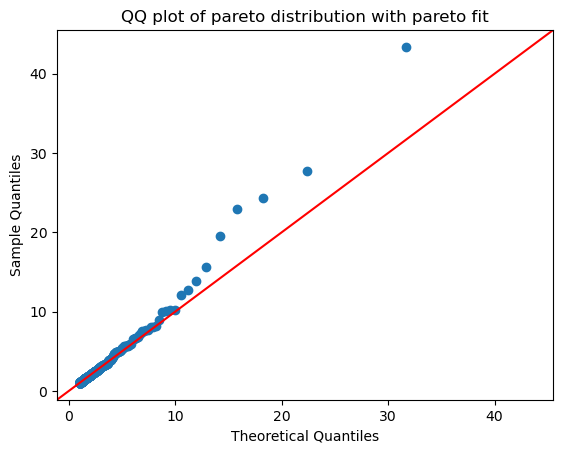

In [49]:
# Create QQ plot of data using pareto distribution:
fig= sm.qqplot(x, dist= distribution, line="45")   
# pichle vaale mein normal distribution as "dist" default tha yahan hamein batana  pdega and yahan fit=True lagane ki zarurat nhi hai

#Add title and labels:
plt.title("QQ plot of pareto distribution with pareto fit")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.show()

## 3. Binomial distribution:

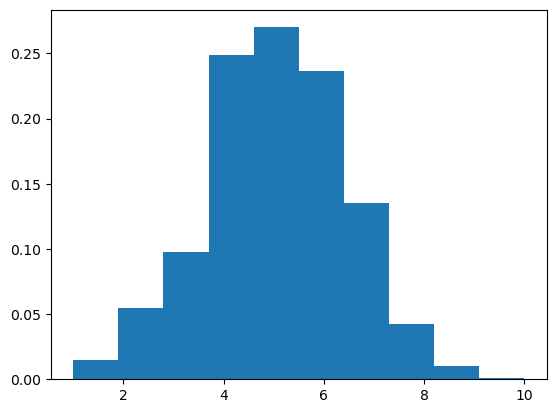

In [52]:
#setting the parameters:
n = 10           # no: of trials
p = 0.5          # probabailty of success : jaise jaise aap yeh value change kroge to graph ki direction bhi change hogi
size = 1000      # no: of samples to generate : means jo above "n", no: of trials hain vo hum kitne baar kr rhe hain

binomial_dist = np.random.binomial(n, p, size)
plt.hist(binomial_dist, density= True)
plt.show()

## 4. Sampling distribution: CENTRAL LIMIT THEOREM

**total sample ko sample size and no: of trials mein devide krdo and individually mean nikaalke unhe sample krdo**

**a. from Uniform distribution:**

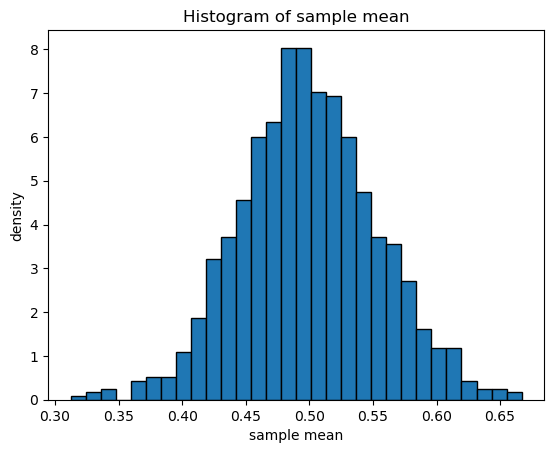

In [54]:
# set parameters:

n = 1000   # no: of trials 
s = 30     # sample size : jitna aap sample size badate jaayoge vo normal distribution ke utne paas aayega
dist_range = (0,1)

# Generate samples from uniform distribution:
samples = np.random.uniform(dist_range[0], dist_range[1], (n,s))

# Calculate sample means:
sample_means = np.mean(samples, axis=1)   # axis=1 means as row wise mean nikaal rhe hain

# Plot the histogram of sample means: 
plt.hist(sample_means, bins = 30, density= True, edgecolor = "black")
plt.title("Histogram of sample mean")
plt.xlabel("sample mean")
plt.ylabel("density")
plt.show()

**b. from exponential distribution:**

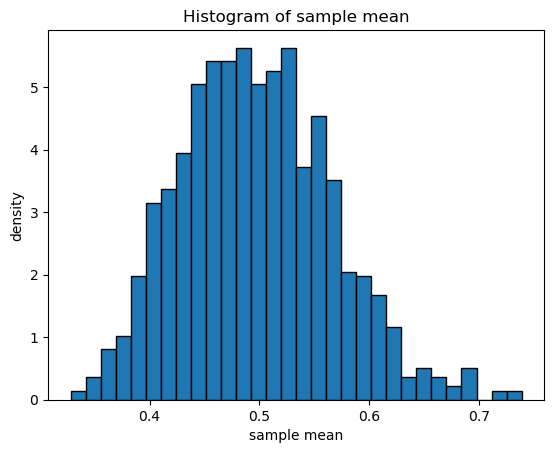

In [55]:
# set parameters:

n = 1000   # no: of trials 
s = 50     # sample size : jitna aap sample size badate jaayoge vo normal distribution ke utne paas aayega
lambda_param =2    # lambda parameter in formula

# Generate samples from exponential distribution:
samples = np.random.exponential(scale= 1/lambda_param, size = (n,s))

# Calculate sample means:
sample_means = np.mean(samples, axis=1)   # axis=1 means as row wise mean nikaal rhe hain

# Plot the histogram of sample means: 
plt.hist(sample_means, bins = 30, density= True, edgecolor = "black")
plt.title("Histogram of sample mean")
plt.xlabel("sample mean")
plt.ylabel("density")
plt.show()

**c. from Poisson distribution, gamma distribution and binomial distribution:**

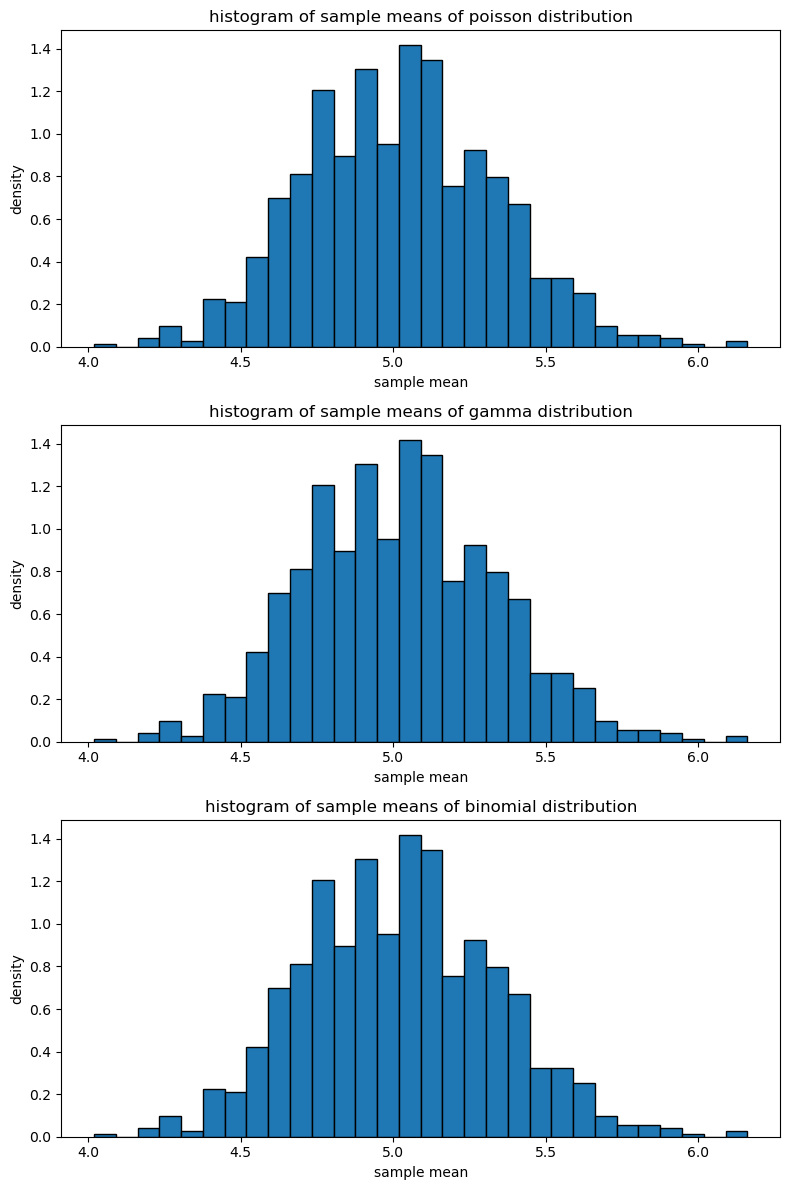

In [57]:
# set parameter:
n = 1000   # no: of trials 
s = 50     # sample size 

# Poisson distribution parameter:
poisson_lambda = 5

# gamma distribution parameter:
gamma_shape = 2
gamma_scale = 1

# binomial distribution parameter:
binomial_n = 10
binomial_p = 0.5

# # Generate samples from distribution:
poisson_samples = np.random.poisson(lam = poisson_lambda, size = (n,s))
gamma_samples = np.random.gamma(shape = gamma_shape, scale = gamma_scale, size = (n,s))
binomial_samples = np.random.binomial(n = binomial_n, p = binomial_p, size = (n,s))

#calculate the sample mean:
poisson_means = np.mean(poisson_samples, axis = 1)
gamma_means = np.mean(gamma_samples, axis = 1)
binomial_means = np.mean(binomial_samples, axis = 1)

# plot the histogram of sample means: as 3 banane hai to unhe set bhi krna hoga using subplot and its axis
fig, axs = plt.subplots(3, 1, figsize = (8,12))

# Poisson distribution plot of mean:
axs[0].hist(poisson_means, bins =30, density=True, edgecolor = "black")
axs[0].set_title("histogram of sample means of poisson distribution")
axs[0].set_xlabel("sample mean")
axs[0].set_ylabel("density")

# gamma distribution plot of mean:
axs[1].hist(poisson_means, bins =30, density=True, edgecolor = "black")
axs[1].set_title("histogram of sample means of gamma distribution")
axs[1].set_xlabel("sample mean")
axs[1].set_ylabel("density")

# binomial distribution plot of mean:
axs[2].hist(poisson_means, bins =30, density=True, edgecolor = "black")
axs[2].set_title("histogram of sample means of binomial distribution")
axs[2].set_xlabel("sample mean")
axs[2].set_ylabel("density")

#adjust the layout and plot:
fig.tight_layout()
plt.show()

## Case study1: Titanic dataset : Central Limit Theorem on "Fare" column:

In [4]:
train_df = pd.read_csv("train_kaggle.csv")
test_df = pd.read_csv("test_kaggle.csv")

In [61]:
# ab dono table ko concat krna hai kyunki vhi complete population banenge jispe central limit theorem lagani hai and ek extra survuve vaala column hatana hai

In [6]:
df = pd.concat([train_df.drop(columns=["Survived"]),test_df]).sample(1309)   #1309 total rows hai to use shuffle kredenge for smapling distribution

In [66]:
df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
691,692,3,"Karun, Miss. Manca",female,4.0,0,1,349256,13.4167,NaN,C
230,1122,2,"Sweet, Mr. George Frederick",male,14.0,0,0,220845,65.0000,NaN,S
399,1291,3,"Conlon, Mr. Thomas Henry",male,31.0,0,0,21332,7.7333,NaN,Q
294,295,3,"Mineff, Mr. Ivan",male,24.0,0,0,349233,7.8958,NaN,S
295,296,1,"Lewy, Mr. Ervin G",male,NaN,0,0,PC 17612,27.7208,NaN,C
...,...,...,...,...,...,...,...,...,...,...,...
16,908,2,"Keane, Mr. Daniel",male,35.0,0,0,233734,12.3500,NaN,Q
45,46,3,"Rogers, Mr. William John",male,NaN,0,0,S.C./A.4. 23567,8.0500,NaN,S
239,240,2,"Hunt, Mr. George Henry",male,33.0,0,0,SCO/W 1585,12.2750,NaN,S
637,638,2,"Collyer, Mr. Harvey",male,31.0,1,1,C.A. 31921,26.2500,NaN,S


<Axes: ylabel='Density'>

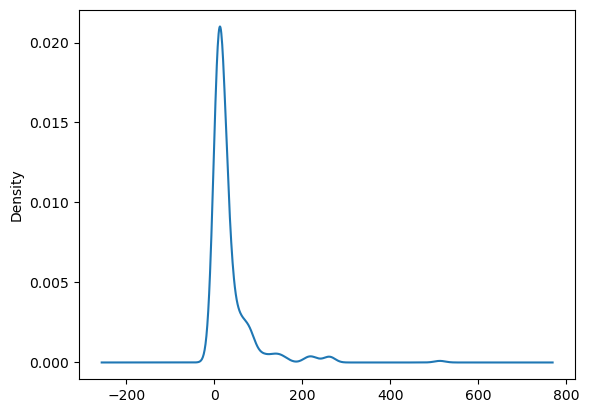

In [10]:
df["Fare"].plot(kind="kde")

In [11]:
# now we perform CETRAL LIMIT THEOREM and create samples with sample_size= 50 and no: of trials=100 so 100 times
samples= []
for i in range(100):
    samples.append(df["Fare"].dropna().sample(50).values.tolist()) # hum jitni baar yeh code run krenge utni baar randomly 50 points aayenge as fare column mein nan values bhi hai use bhi remove krna hai

In [12]:
samples = np.array(samples)
samples

array([[106.425 ,  23.    ,  77.9583, ...,   7.575 ,   6.95  ,   7.775 ],
       [ 12.1833,  65.    ,   7.225 , ...,   7.75  ,   7.8958,  16.7   ],
       [ 10.5   ,  36.75  ,  79.2   , ...,   8.6625,  16.1   ,  29.    ],
       ...,
       [  6.75  ,  29.125 , 135.6333, ...,   0.    ,   8.05  ,  26.55  ],
       [ 26.    , 151.55  ,  36.75  , ...,  13.    ,  35.5   ,   8.6625],
       [ 15.9   ,  86.5   ,   9.225 , ...,  26.    ,  10.4625,  50.    ]],
      shape=(100, 50))

In [18]:
sampling_mean= np.mean(samples, axis=1)      # ab saare samples and sampling mean nikaalna hai

<Axes: ylabel='Density'>

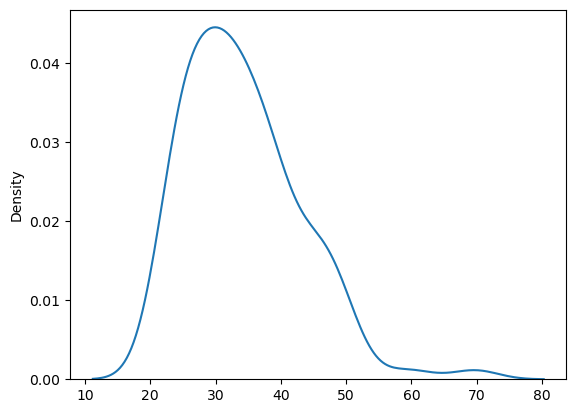

In [19]:
sns.kdeplot(sampling_mean)

In [20]:
# if we find out sample mean value of resultand normal distribution:
normal_mean = sampling_mean.mean()
normal_mean

np.float64(34.22083558)

In [21]:
# if we find out sample std value of resultant normal distribution:

normal_std = sampling_mean.std()/np.sqrt(50) 
normal_std 
# hamein pata hai ki resultant normal distribution ka variance = original population variance/sample_size hota hai
# but yahan varian nhi std so dono ka sqrt krenge so 
# sqrt(variance)= std and sqrt(sample_size) = sqrt(50) as 50 is sample_size in gthis case

np.float64(1.2414875444993774)

**hamein pata hai ki resultant normal distribution ka variance = original population variance/sample_size hota hai
but yahan varian nhi std so dono ka sqrt krenge so 
sqrt(variance)= std and sqrt(sample_size) = sqrt(50) as 50 is sample_size in this case**

In [96]:
# one more thing hamein pata hai EMPERICAL RULE ke according 95% of data mean- 2*std se leke mean+2*std tak hota hai so find upper and lower limits: 

lower_limit = normal_mean - 2*(normal_std)
upper_limit = normal_mean + 2*(normal_std)
print("the range is", lower_limit, "-", upper_limit)

the range is 30.23293812230724 - 34.26303955769277


**what we are saying that original population ka mean is range mein aane ki chance 95% hai (from empirical rule)**

**so what we are doing now to find actual population mean matlab Fare column ka mean**

In [22]:
df["Fare"].mean()   # which lies in this above calculated range 

np.float64(33.29547928134557)